# ANOVA (Analysis of Variance)

Referencia: *Practical Statistics for Data Scientists* — Bruce & Bruce

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

## Notas

In [7]:
rng = np.random.default_rng(seed=42)

data = pd.DataFrame(
    {
        "method": np.repeat(["French Press", "Pour Over", "Espresso"], 40),
        "rating": np.concatenate(
            [
                rng.normal(4.0, 0.5, 40),  # French Press ratings
                rng.normal(4.5, 0.5, 40),  # Pour Over ratings
                rng.normal(4.8, 0.5, 40),  # Espresso ratings
            ]
        ),
    }
)


# ANOVA test
f_statistic, p_value = stats.f_oneway(
    data[data["method"] == "French Press"]["rating"],
    data[data["method"] == "Pour Over"]["rating"],
    data[data["method"] == "Espresso"]["rating"],
)

print(f"F-statistic: {f_statistic:.2f}, p-value: {p_value:.4f}")

F-statistic: 31.00, p-value: 0.0000


/var/folders/t9/t_rpjxld77qckx9g0kl5kwn00000gn/T/ipykernel_43377/437217327.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="method", y="rating", data=data, ax=ax[0], palette="Set2")


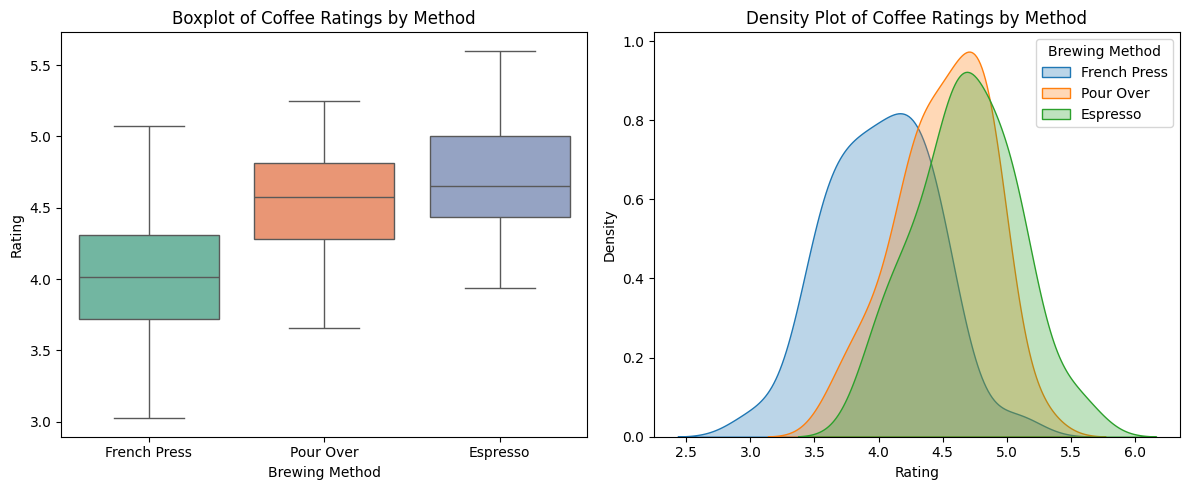

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="method", y="rating", data=data, ax=ax[0], palette="Set2")
ax[0].set_title("Boxplot of Coffee Ratings by Method")
ax[0].set_xlabel("Brewing Method")
ax[0].set_ylabel("Rating")

for method in data["method"].unique():
    subset = data[data["method"] == method]
    sns.kdeplot(subset["rating"], ax=ax[1], label=method, fill=True, alpha=0.3)

ax[1].set_title("Density Plot of Coffee Ratings by Method")
ax[1].set_xlabel("Rating")
ax[1].set_ylabel("Density")
ax[1].legend(title="Brewing Method")

plt.tight_layout()
plt.show()

## Entendiendo F paso a paso

**F = Señal / Ruido**

- **Señal (varianza ENTRE grupos):** ¿Qué tanto difieren los promedios de cada grupo del promedio general?
- **Ruido (varianza DENTRO de grupos):** ¿Qué tanto varían los datos dentro de cada grupo?

Si F es grande → las diferencias entre grupos son mayores que la variación interna → los grupos son realmente diferentes.

In [14]:
# Promedios por grupo
promedios = data.groupby("method")["rating"].mean()
promedio_general = data["rating"].mean()

print("Promedios por grupo:")
print(promedios.to_string())
print(f"\nPromedio general: {promedio_general:.2f}")

# --- SEÑAL: varianza ENTRE grupos ---
n = 40  # clientes por grupo
señal = sum(n * (prom - promedio_general) ** 2 for prom in promedios)
señal = señal / (3 - 1)  # dividir entre (k-1), k=3 grupos

# --- RUIDO: varianza DENTRO de grupos ---
ruido = 0
for method, prom in promedios.items():
    datos_grupo = data[data["method"] == method]["rating"]
    ruido += sum((x - prom) ** 2 for x in datos_grupo)
ruido = ruido / (120 - 3)  # dividir entre (N-k)

# --- F ---
F = señal / ruido
print(f"\nSeñal (varianza entre grupos): {señal:.2f}")
print(f"Ruido (varianza dentro de grupos): {ruido:.2f}")
print(f"\nF = {señal:.2f} / {ruido:.2f} = {F:.2f}")
print(f"F de scipy: {f_statistic:.2f}")  # debe coincidir

Promedios por grupo:
method
Espresso        4.683676
French Press    4.019133
Pour Over       4.506589

Promedio general: 4.40

Señal (varianza entre grupos): 4.74
Ruido (varianza dentro de grupos): 0.15

F = 4.74 / 0.15 = 31.00
F de scipy: 31.00
